# 1 Import necessary library

---



In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.model_selection import train_test_split


#  Mount Google Drive & Set Paths

In [31]:
from google.colab import drive
drive.mount('/content/drive')

# Our data correct path
dataset_path = "/content/drive/MyDrive/DL_Projects /DL_PRO/data"
print("Data exists:", os.path.exists(dataset_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data exists: True


# Step 2: Exploratory Data Analysis

In [6]:
# Check train and test folders
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

print("Train classes:", os.listdir(train_path))
print("Test classes:", os.listdir(test_path))

# Count images in each class
print("\n Training set:")
for class_name in os.listdir(train_path):
    class_folder = os.path.join(train_path, class_name)
    count = len(os.listdir(class_folder))
    print(f"  {class_name}: {count} images")

print("\n Test set:")
for class_name in os.listdir(test_path):
    class_folder = os.path.join(test_path, class_name)
    count = len(os.listdir(class_folder))
    print(f"  {class_name}: {count} images")

Train classes: ['Phoma', 'Leaf rust', 'Healthy', 'Cerscospora']
Test classes: ['Phoma', 'Leaf rust', 'Cerscospora', 'Healthy']

 Training set:
  Phoma: 2700 images
  Leaf rust: 2700 images
  Healthy: 2700 images
  Cerscospora: 2700 images

 Test set:
  Phoma: 300 images
  Leaf rust: 300 images
  Cerscospora: 300 images
  Healthy: 300 images


              DATASET STATISTICS


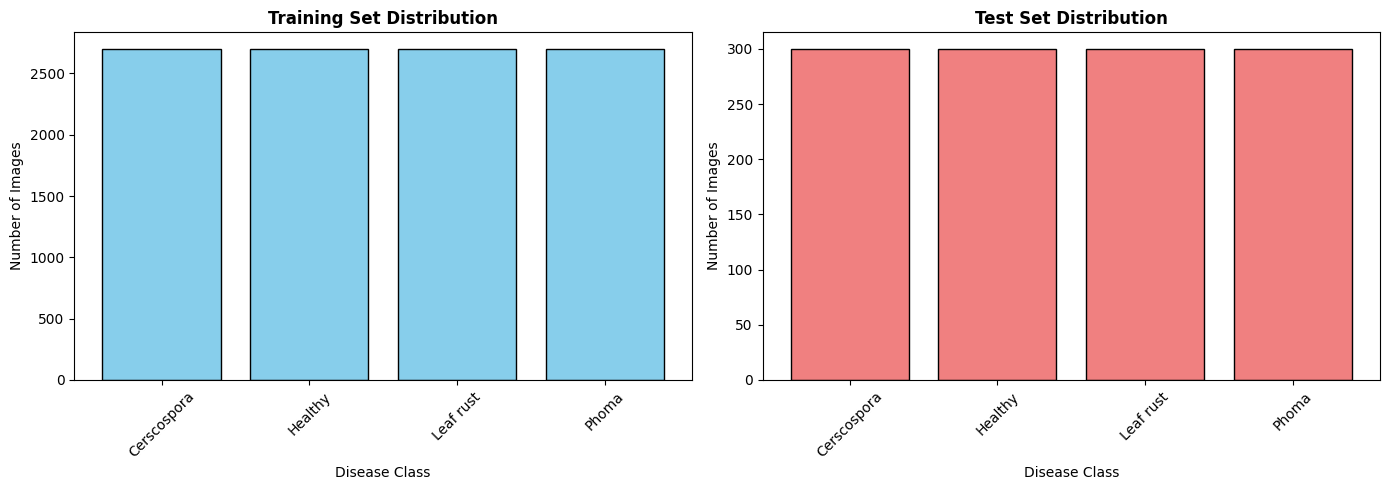


 Training Set:
  Cerscospora    : 2700 images (25.0%)
  Healthy        : 2700 images (25.0%)
  Leaf rust      : 2700 images (25.0%)
  Phoma          : 2700 images (25.0%)

 Test Set:
  Cerscospora    : 300 images (25.0%)
  Healthy        : 300 images (25.0%)
  Leaf rust      : 300 images (25.0%)
  Phoma          : 300 images (25.0%)


In [7]:
# 2.1 Dataset Statistics
print("="*50)
print("              DATASET STATISTICS")
print("="*50)

train_stats = {}
for class_name in class_names:
    class_folder = os.path.join(train_path, class_name)
    train_stats[class_name] = len(os.listdir(class_folder))

test_stats = {}
for class_name in class_names:
    class_folder = os.path.join(test_path, class_name)
    test_stats[class_name] = len(os.listdir(class_folder))

# Bar plot of class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(train_stats.keys(), train_stats.values(), color='skyblue', edgecolor='black')
ax1.set_title('Training Set Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Disease Class')
ax1.set_ylabel('Number of Images')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(test_stats.keys(), test_stats.values(), color='lightcoral', edgecolor='black')
ax2.set_title('Test Set Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Disease Class')
ax2.set_ylabel('Number of Images')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print statistics
print("\n Training Set:")
for class_name, count in train_stats.items():
    print(f"  {class_name:15s}: {count:3d} images ({count/sum(train_stats.values())*100:.1f}%)")

print("\n Test Set:")
for class_name, count in test_stats.items():
    print(f"  {class_name:15s}: {count:3d} images ({count/sum(test_stats.values())*100:.1f}%)")

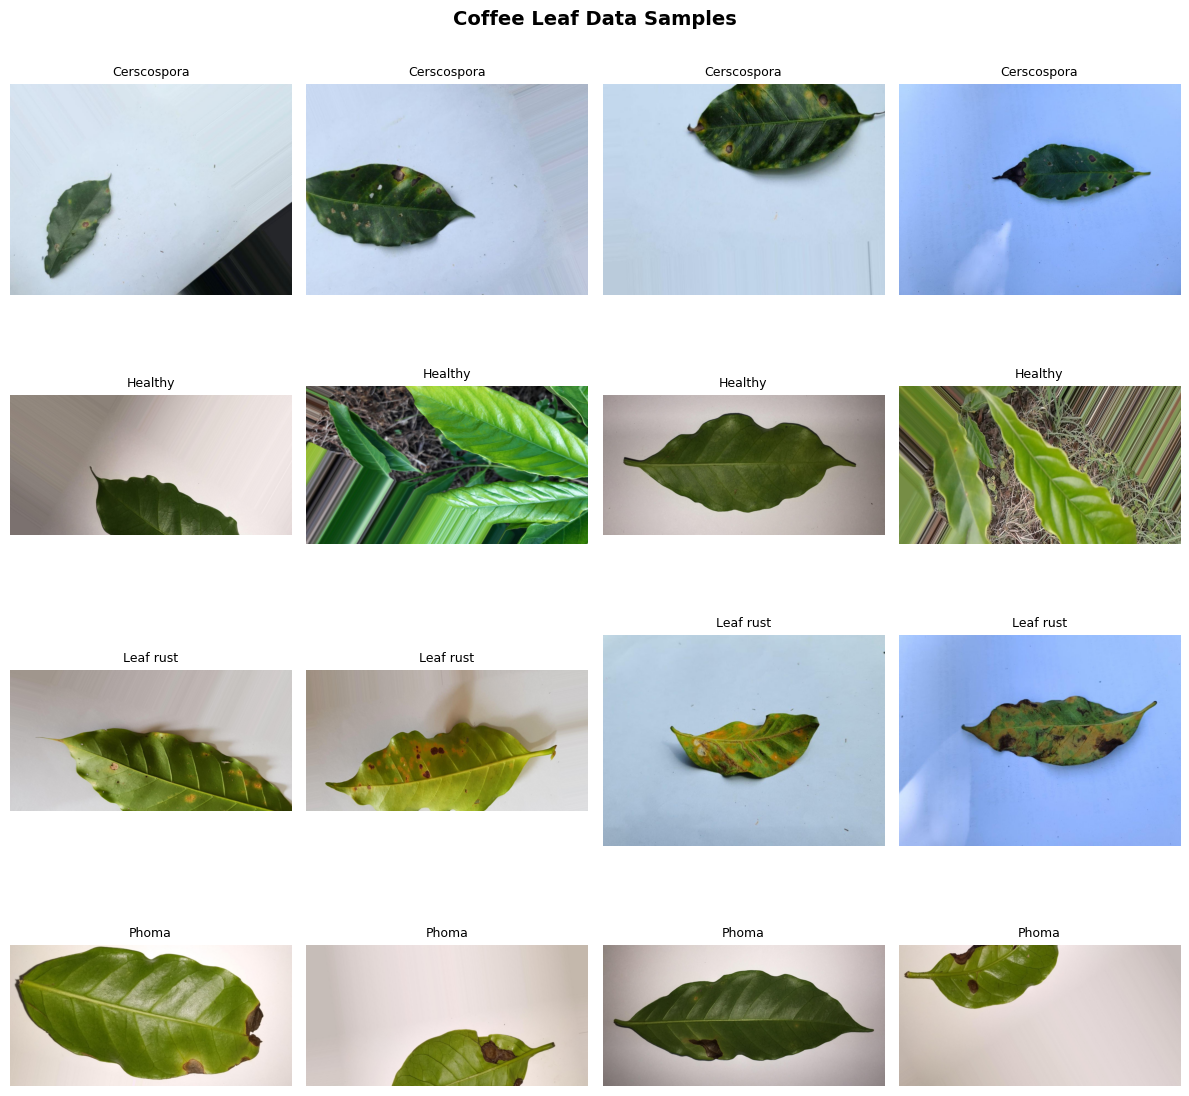

In [5]:
# 2.2  Display 16 images samples ( 4 for ech class )
train_path = os.path.join(dataset_path, "train")
class_names = sorted(os.listdir(train_path))

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Coffee Leaf Data Samples', fontsize=14, fontweight='bold')

for class_idx, class_name in enumerate(class_names):
    class_path = os.path.join(train_path, class_name)
    images = random.sample(os.listdir(class_path), 4)

    for img_idx, img_name in enumerate(images):
        img = cv2.cvtColor(cv2.imread(os.path.join(class_path, img_name)), cv2.COLOR_BGR2RGB)
        axes[class_idx, img_idx].imshow(img)
        axes[class_idx, img_idx].set_title(f'{class_name}', fontsize=9)
        axes[class_idx, img_idx].axis('off')

plt.tight_layout()
plt.show()

# Image Quality Analysis

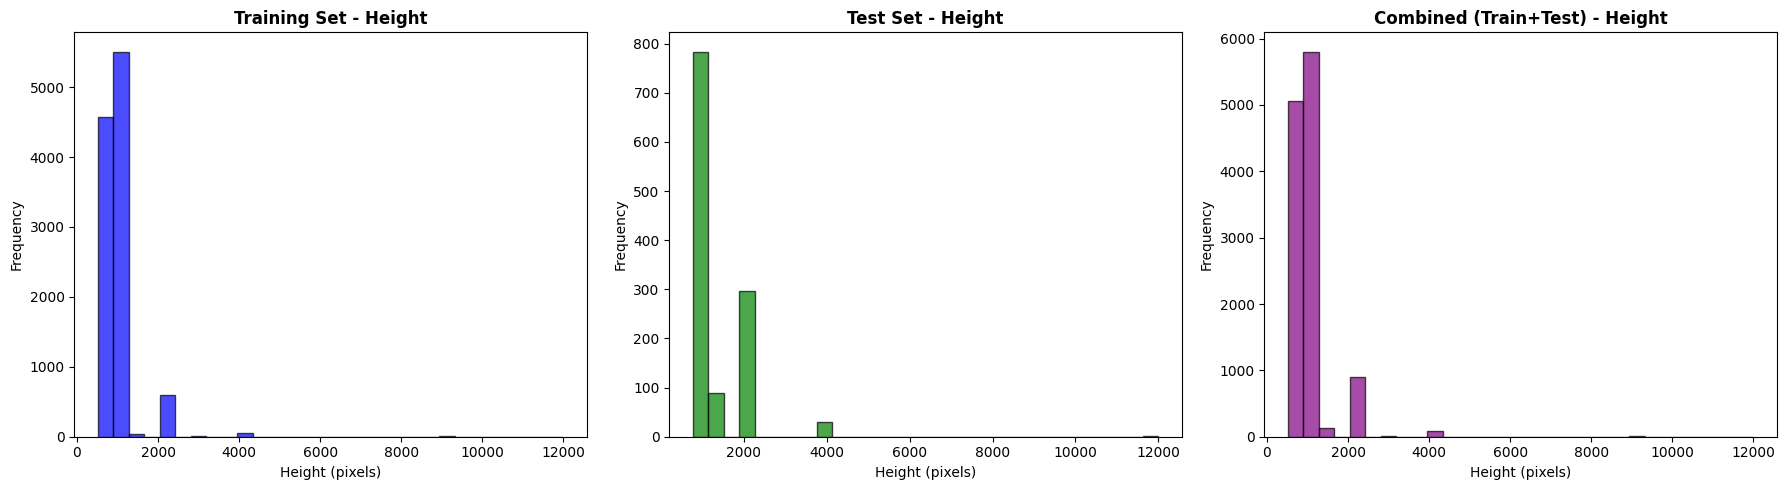


 TRAINING SET STATISTICS:
  Height Range: 512 - 12000 pixels
  Width Range: 576 - 12000 pixels
  Average Height: 1015 pixels
  Average Width: 1643 pixels

 TEST SET STATISTICS:
  Height Range: 768 - 12000 pixels
  Width Range: 576 - 9000 pixels
  Average Height: 1276 pixels
  Average Width: 1323 pixels

 COMBINED (TRAIN + TEST) STATISTICS:
  Height Range: 512 - 12000 pixels
  Width Range: 576 - 12000 pixels
  Average Height: 1041 pixels
  Average Width: 1611 pixels


In [8]:
# Analyze image properties with all data (training + testing)
def analyze_image_properties(folder_path):
    heights, widths = [], []

    for class_name in class_names:
        class_folder = os.path.join(folder_path, class_name)
        all_images = os.listdir(class_folder)

        for img_name in all_images:
            img = cv2.imread(os.path.join(class_folder, img_name))
            if img is not None:
                h, w = img.shape[:2]
                heights.append(h)
                widths.append(w)

    return heights, widths

# Analyze BOTH training AND test data
train_heights, train_widths = analyze_image_properties(train_path)
test_heights, test_widths = analyze_image_properties(test_path)

# Combine all data
all_heights = train_heights + test_heights
all_widths = train_widths + test_widths

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training distribution
axes[0].hist(train_heights, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Training Set - Height', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Height (pixels)')
axes[0].set_ylabel('Frequency')

# Test distribution
axes[1].hist(test_heights, bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Test Set - Height', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Frequency')

# Combined distribution
axes[2].hist(all_heights, bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[2].set_title('Combined (Train+Test) - Height', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Height (pixels)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print statistics for all datasets
print(f"\n TRAINING SET STATISTICS:")
print(f"  Height Range: {min(train_heights)} - {max(train_heights)} pixels")
print(f"  Width Range: {min(train_widths)} - {max(train_widths)} pixels")
print(f"  Average Height: {np.mean(train_heights):.0f} pixels")
print(f"  Average Width: {np.mean(train_widths):.0f} pixels")

print(f"\n TEST SET STATISTICS:")
print(f"  Height Range: {min(test_heights)} - {max(test_heights)} pixels")
print(f"  Width Range: {min(test_widths)} - {max(test_widths)} pixels")
print(f"  Average Height: {np.mean(test_heights):.0f} pixels")
print(f"  Average Width: {np.mean(test_widths):.0f} pixels")

print(f"\n COMBINED (TRAIN + TEST) STATISTICS:")
print(f"  Height Range: {min(all_heights)} - {max(all_heights)} pixels")
print(f"  Width Range: {min(all_widths)} - {max(all_widths)} pixels")
print(f"  Average Height: {np.mean(all_heights):.0f} pixels")
print(f"  Average Width: {np.mean(all_widths):.0f} pixels")

# 3. Data Analysis & Preprocessing

---




In [13]:
# Paths
dataset_path = "/content/drive/MyDrive/DL_Projects /DL_PRO/data"
train_path = os.path.join(dataset_path, "train")
class_names = sorted(os.listdir(train_path))

print("="*50)
print("         BRIGHTNESS & CONTRAST CHECK")
print("="*50)

# Store results
all_brightness = []
all_contrast = []

# Check 10 images per class
for class_name in class_names:
    class_folder = os.path.join(train_path, class_name)
    images = os.listdir(class_folder)[:10]  # First 10 images

    for img_name in images:
        img = cv2.imread(os.path.join(class_folder, img_name))
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            brightness = np.mean(gray)
            contrast = np.std(gray)

            all_brightness.append(brightness)
            all_contrast.append(contrast)

# Calculate min, max, average
brightness_min = np.min(all_brightness)
brightness_max = np.max(all_brightness)
brightness_avg = np.mean(all_brightness)

contrast_min = np.min(all_contrast)
contrast_max = np.max(all_contrast)
contrast_avg = np.mean(all_contrast)

# Convert to percentage
brightness_min_pct = brightness_min / 255 * 100
brightness_max_pct = brightness_max / 255 * 100
brightness_avg_pct = brightness_avg / 255 * 100

# Print results
print(f"\n RESULTS:")
print(f"Brightness - Min: {brightness_min_pct:.1f}% | Max: {brightness_max_pct:.1f}% | Avg: {brightness_avg_pct:.1f}%")
print(f"Contrast   - Min: {contrast_min:.1f} | Max: {contrast_max:.1f} | Avg: {contrast_avg:.1f}")

# Decision
print(f"\n{'='*50}")
print("DECISION:")
print(f"{'='*50}")

# Check if fair
if (brightness_min_pct >= 30 and brightness_max_pct <= 85 and
    contrast_min >= 20 and contrast_avg >= 30):
    print(" DATASET IS FAIR - Ready for training!")
else:
    print(" DATASET NEEDS PREPROCESSING")
    print("\nIssues found:")
    if brightness_min_pct < 30:
        print(f"  - Too dark: {brightness_min_pct:.1f}% < 30%")
    if brightness_max_pct > 85:
        print(f"  - Too bright: {brightness_max_pct:.1f}% > 85%")
    if contrast_min < 20:
        print(f"  - Low contrast: {contrast_min:.1f} < 20")
    if contrast_avg < 30:
        print(f"  - Poor average contrast: {contrast_avg:.1f} < 30")

         BRIGHTNESS & CONTRAST CHECK

 RESULTS:
Brightness - Min: 37.6% | Max: 82.9% | Avg: 64.3%
Contrast   - Min: 27.7 | Max: 70.1 | Avg: 47.7

DECISION:
 DATASET IS FAIR - Ready for training!



 IMAGE QUALITY ANALYSIS

Cerscospora:
  Sample: aug_0_566.jpeg
  Brightness: 162.08/255 (63.6%)
  Contrast: 49.82

Healthy:
  Sample: aug_0_6050.jpeg
  Brightness: 186.22/255 (73.0%)
  Contrast: 47.38

Leaf rust:
  Sample: aug_0_1405.jpeg
  Brightness: 181.81/255 (71.3%)
  Contrast: 54.35

Phoma:
  Sample: aug_2_573 (2).jpg
  Brightness: 181.72/255 (71.3%)
  Contrast: 56.64


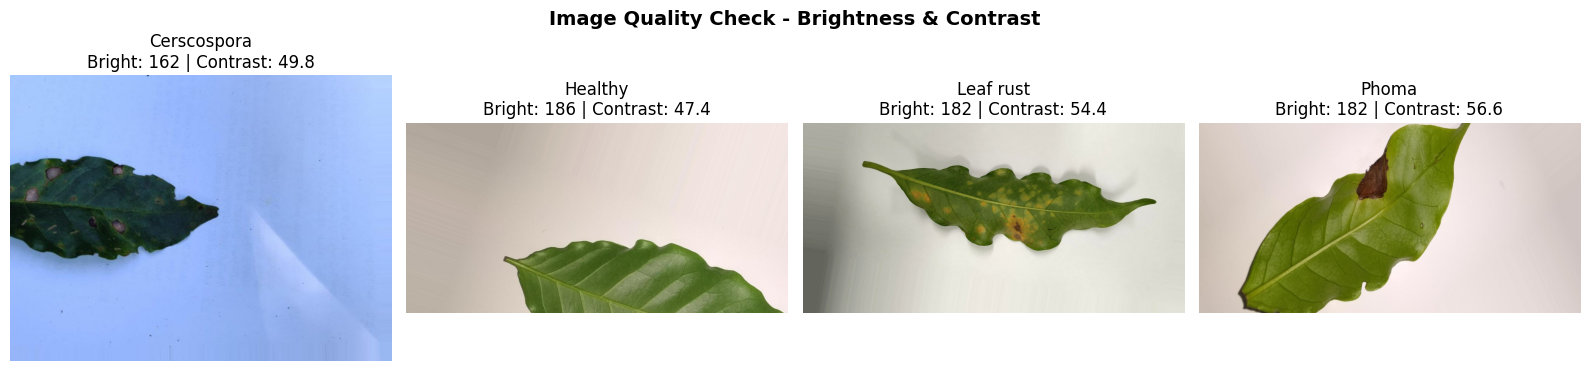

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Define preprocessing functions
def analyze_brightness(image):
    """Calculate image brightness"""
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return np.mean(image)

def analyze_contrast(image):
    """Calculate image contrast (standard deviation)"""
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return np.std(image)

# 4.2 Check image quality metrics
print("\n" + "="*50)
print(" IMAGE QUALITY ANALYSIS")
print("="*50)

sample_images = []
sample_labels = []

for class_name in class_names:
    class_folder = os.path.join(train_path, class_name)
    sample_file = random.choice(os.listdir(class_folder))
    img_path = os.path.join(class_folder, sample_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    brightness = analyze_brightness(img)
    contrast = analyze_contrast(img)

    print(f"\n{class_name}:")
    print(f"  Sample: {sample_file[:30]}")
    print(f"  Brightness: {brightness:.2f}/255 ({brightness/255*100:.1f}%)")
    print(f"  Contrast: {contrast:.2f}")

    sample_images.append(img)
    sample_labels.append(class_name)

# Display quality metrics
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Image Quality Check - Brightness & Contrast', fontsize=14, fontweight='bold')

for idx, (img, label) in enumerate(zip(sample_images, sample_labels)):
    axes[idx].imshow(img)
    brightness = analyze_brightness(img)
    contrast = analyze_contrast(img)
    axes[idx].set_title(f'{label}\nBright: {brightness:.0f} | Contrast: {contrast:.1f}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Data Augmentation Visualization

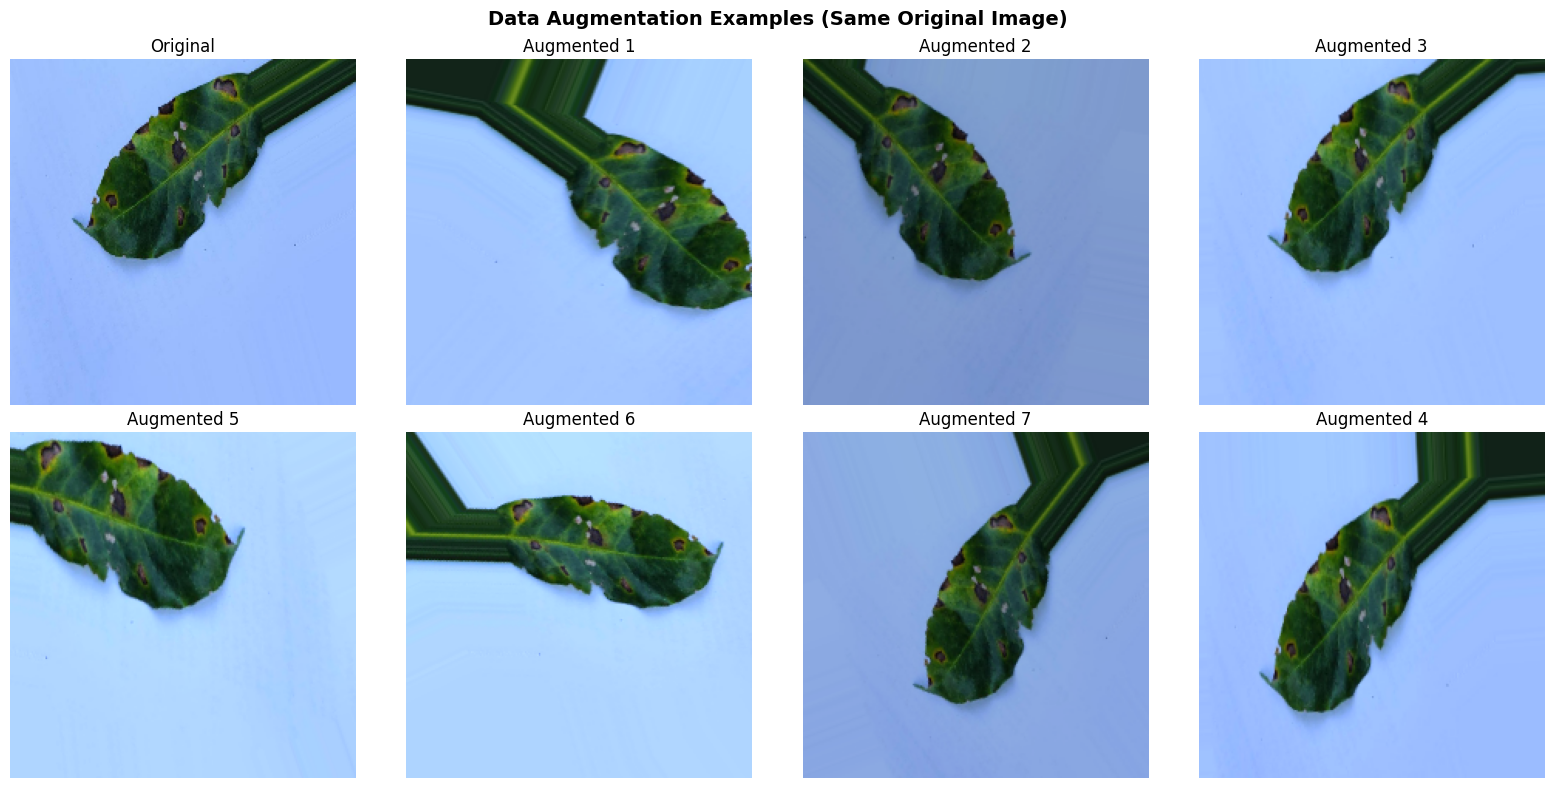


 Data Augmentation Techniques Applied:
  • Rotation (0-30°)
  • Width/Height Shift (20%)
  • Shear (20%)
  • Zoom (20%)
  • Horizontal Flip
  • Brightness Adjustment (80-120%)


In [16]:
#  Create augmentation pipeline
augmentation_gen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

#  Visualize augmentations on one image
sample_img_path = os.path.join(train_path, class_names[0], os.listdir(os.path.join(train_path, class_names[0]))[0])
sample_img = load_img(sample_img_path, target_size=(224, 224))
sample_array = img_to_array(sample_img)
sample_array = sample_array.reshape((1,) + sample_array.shape)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Data Augmentation Examples (Same Original Image)', fontsize=14, fontweight='bold')

# Original image
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Generate augmented versions
for i in range(7):
    aug_iter = augmentation_gen.flow(sample_array, batch_size=1)
    aug_img = next(aug_iter)[0].astype('uint8')

    row = i // 4 + 1 if i >= 4 else 0
    col = i % 4 if i < 4 else i - 4

    if i < 3:  # First row (after original)
        axes[0, i+1].imshow(aug_img)
        axes[0, i+1].set_title(f'Augmented {i+1}')
        axes[0, i+1].axis('off')
    else:  # Second row
        axes[1, i-4].imshow(aug_img)
        axes[1, i-4].set_title(f'Augmented {i+1}')
        axes[1, i-4].axis('off')

plt.tight_layout()
plt.show()

print("\n Data Augmentation Techniques Applied:")
print("  • Rotation (0-30°)")
print("  • Width/Height Shift (20%)")
print("  • Shear (20%)")
print("  • Zoom (20%)")
print("  • Horizontal Flip")
print("  • Brightness Adjustment (80-120%)")

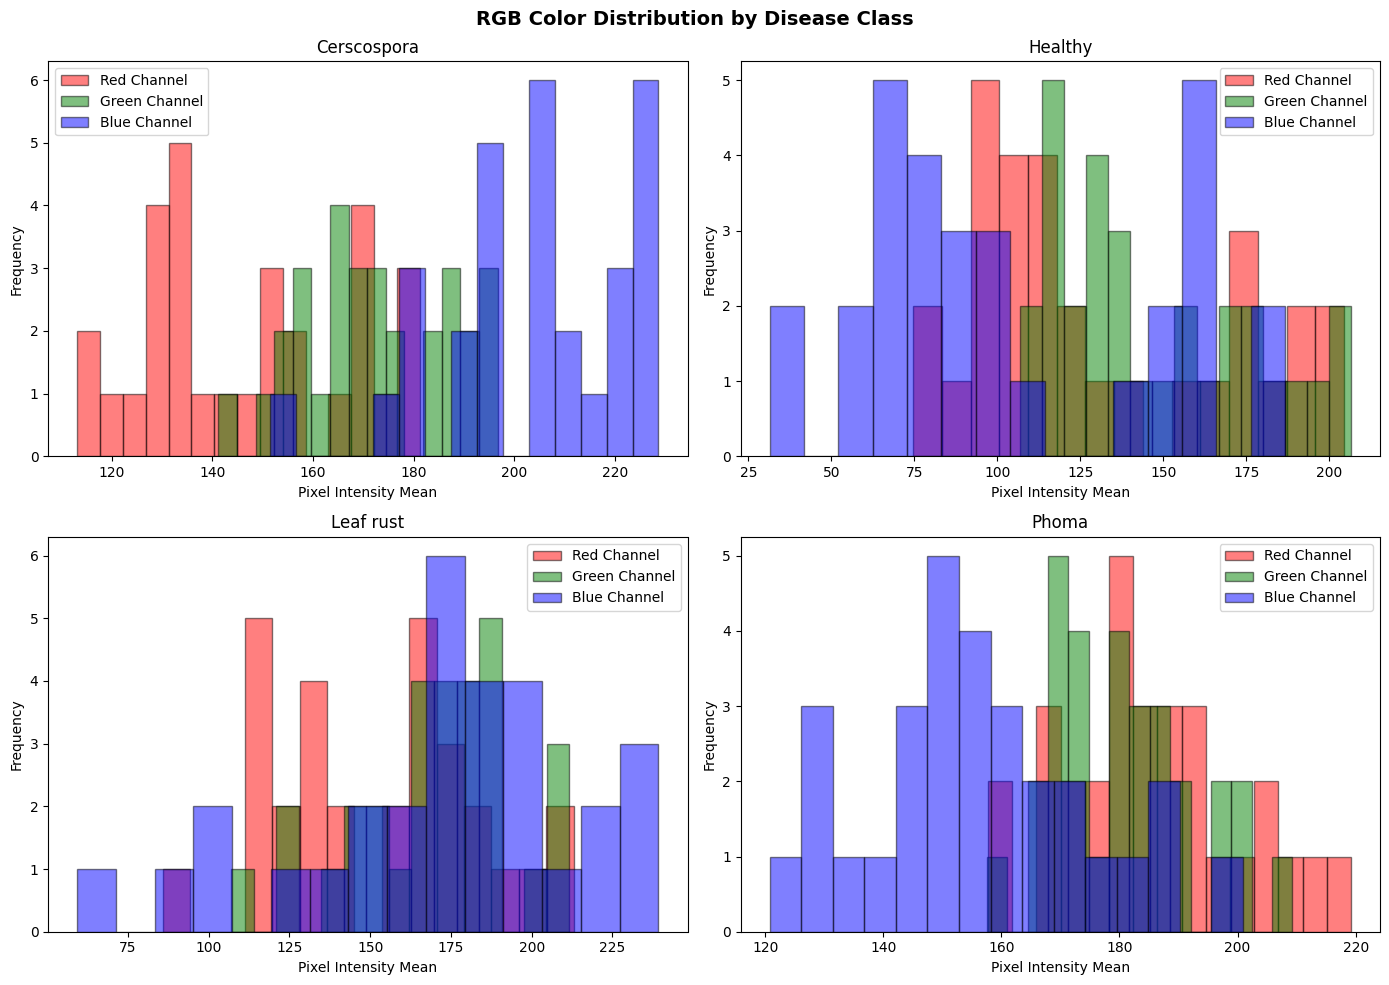


 Average RGB Values per Class:
  Cerscospora    : R=146.8, G=172.4, B=204.1
  Healthy        : R=130.3, G=147.7, B=103.8
  Leaf rust      : R=152.1, G=169.3, B=171.7
  Phoma          : R=185.4, G=180.5, B=156.0


In [17]:
#  Analyze RGB channels for each class
def analyze_color_distribution(folder_path, num_samples=30):
    color_stats = {class_name: {'R': [], 'G': [], 'B': []} for class_name in class_names}

    for class_name in class_names:
        class_folder = os.path.join(folder_path, class_name)
        images = os.listdir(class_folder)[:num_samples]

        for img_name in images:
            img = cv2.imread(os.path.join(class_folder, img_name))
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                color_stats[class_name]['R'].append(np.mean(img_rgb[:,:,0]))
                color_stats[class_name]['G'].append(np.mean(img_rgb[:,:,1]))
                color_stats[class_name]['B'].append(np.mean(img_rgb[:,:,2]))

    return color_stats

color_stats = analyze_color_distribution(train_path)

# Plot color distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RGB Color Distribution by Disease Class', fontsize=14, fontweight='bold')

for idx, class_name in enumerate(class_names):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]

    r_means = color_stats[class_name]['R']
    g_means = color_stats[class_name]['G']
    b_means = color_stats[class_name]['B']

    ax.hist(r_means, bins=15, alpha=0.5, color='red', label='Red Channel', edgecolor='black')
    ax.hist(g_means, bins=15, alpha=0.5, color='green', label='Green Channel', edgecolor='black')
    ax.hist(b_means, bins=15, alpha=0.5, color='blue', label='Blue Channel', edgecolor='black')

    ax.set_title(f'{class_name}')
    ax.set_xlabel('Pixel Intensity Mean')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

# Print average color values
print("\n Average RGB Values per Class:")
for class_name in class_names:
    r_avg = np.mean(color_stats[class_name]['R'])
    g_avg = np.mean(color_stats[class_name]['G'])
    b_avg = np.mean(color_stats[class_name]['B'])
    print(f"  {class_name:15s}: R={r_avg:.1f}, G={g_avg:.1f}, B={b_avg:.1f}")

# Data Splitting & Preparation for Modeling

In [19]:
# Define paths
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

# Create data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Take 20% from train as validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 8640 images belonging to 4 classes.
Found 2160 images belonging to 4 classes.
Found 1200 images belonging to 4 classes.


#  Build Baseline CNN Model

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,596 (84.86 MB)

 Trainable params: 22,246,148 (84.86 MB)

 Non-trainable params: 448 (1.75 KB)

# Train with Callbacks

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True),
    ReduceLROnPlateau(factor=0.2, patience=3)
]

# Train
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.6329 - loss: 14.2938 - precision: 0.6348 - recall: 0.6312

270/270 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.6591 - loss: 8.9503 - precision: 0.6616 - recall: 0.6564 - val_accuracy: 0.2532 - val_loss: 22.8713 - val_precision: 0.2532 - val_recall: 0.2532 - learning_rate: 0.0010
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.7236 - loss: 0.9863 - precision: 0.7542 - recall: 0.6774

270/270 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.7179 - loss: 0.9246 - precision: 0.7563 - recall: 0.6601 - val_accuracy: 0.4426 - val_loss: 1.8568 - val_precision: 0.4523 - val_recall: 0.4065 - learning_rate: 0.0010
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 269s 998ms/step - accuracy: 0.7463 - loss: 0.6473 - precision: 0.7851 - recall: 0.6964 - val_accuracy: 0.6014 - val_loss: 2.7041 - val_precision: 0.6116 - val_recall: 0.5861 - learning_rate: 0.0010
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 269s 996ms/step - accuracy: 0.7536 - loss: 0.6581 - precision: 0.7918 - recall: 0.6969 - val_accuracy: 0.5162 - val_loss: 4.1966 - val_precision: 0.5312 - val_recall: 0.5116 - learning_rate: 0.0010
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.7412 - loss: 0.7099 - precision: 0.7994 - recall: 0.6730

270/270 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.7497 - loss: 0.6961 - precision: 0.7993 - recall: 0.6841 - val_accuracy: 0.7116 - val_loss: 1.1757 - val_precision: 0.7348 - val_recall: 0.6644 - learning_rate: 0.0010
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - accuracy: 0.7656 - loss: 0.6215 - precision: 0.8053 - recall: 0.7123

270/270 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.7747 - loss: 0.6295 - precision: 0.8154 - recall: 0.7141 - val_accuracy: 0.7847 - val_loss: 0.7646 - val_precision: 0.8021 - val_recall: 0.7694 - learning_rate: 0.0010
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 270s 999ms/step - accuracy: 0.7895 - loss: 0.6040 - precision: 0.8284 - recall: 0.7284 - val_accuracy: 0.5769 - val_loss: 2.5297 - val_precision: 0.6896 - val_recall: 0.5523 - learning_rate: 0.0010
Epoch 8/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.8145 - loss: 0.5033 - precision: 0.8523 - recall: 0.7591

270/270 ━━━━━━━━━━━━━━━━━━━━ 269s 997ms/step - accuracy: 0.8102 - loss: 0.5182 - precision: 0.8463 - recall: 0.7579 - val_accuracy: 0.8028 - val_loss: 0.7554 - val_precision: 0.8120 - val_recall: 0.7838 - learning_rate: 0.0010
Epoch 9/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 802ms/step - accuracy: 0.8167 - loss: 0.5193 - precision: 0.8520 - recall: 0.7555

270/270 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - accuracy: 0.8140 - loss: 0.5299 - precision: 0.8514 - recall: 0.7563 - val_accuracy: 0.8245 - val_loss: 0.6844 - val_precision: 0.8346 - val_recall: 0.8130 - learning_rate: 0.0010
Epoch 10/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.8195 - loss: 0.4828 - precision: 0.8594 - recall: 0.7688

270/270 ━━━━━━━━━━━━━━━━━━━━ 288s 1s/step - accuracy: 0.8328 - loss: 0.4666 - precision: 0.8708 - recall: 0.7845 - val_accuracy: 0.8894 - val_loss: 0.4354 - val_precision: 0.9275 - val_recall: 0.8347 - learning_rate: 0.0010


# Training Performance

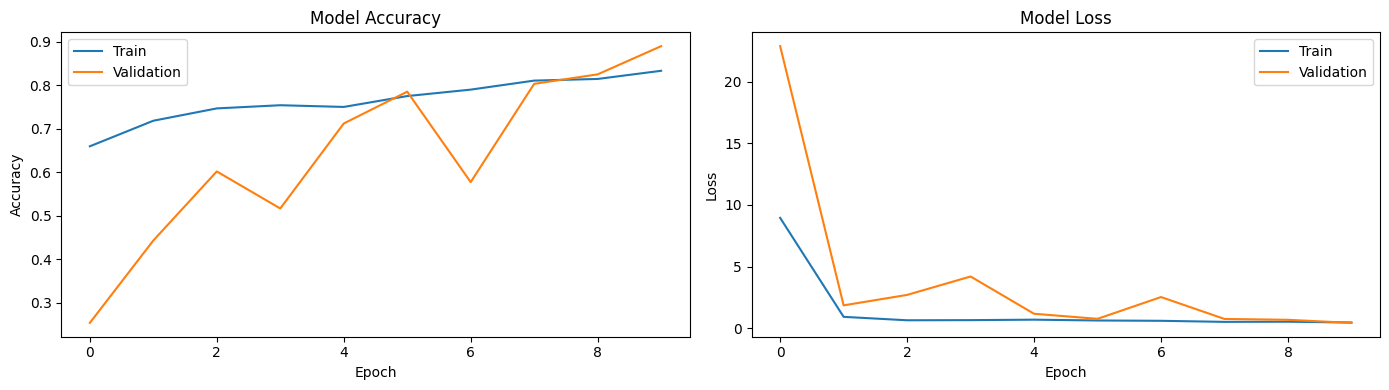

In [38]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

# Evaluate on Test Set

38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 546ms/step - accuracy: 0.8583 - loss: 0.5289 - precision: 0.8750 - recall: 0.8458

  Test Results:
  Accuracy: 85.83%
  Precision: 87.50%
  Recall: 84.58%
38/38 ━━━━━━━━━━━━━━━━━━━━ 24s 619ms/step


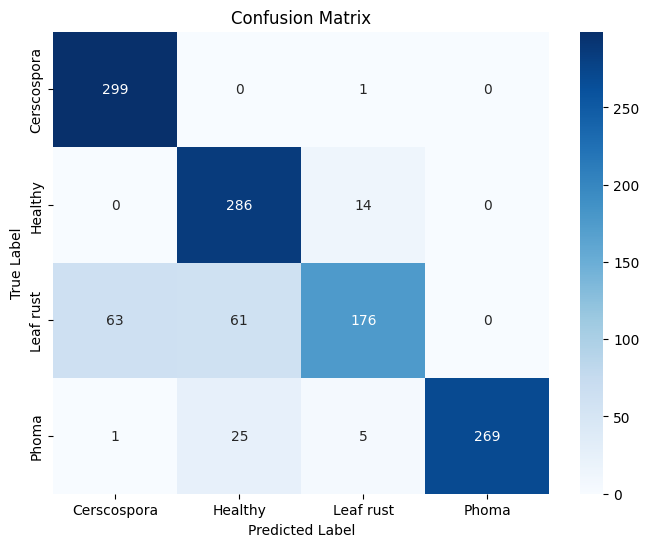


Classification Report:
              precision    recall  f1-score   support

 Cerscospora       0.82      1.00      0.90       300
     Healthy       0.77      0.95      0.85       300
   Leaf rust       0.90      0.59      0.71       300
       Phoma       1.00      0.90      0.95       300

    accuracy                           0.86      1200
   macro avg       0.87      0.86      0.85      1200
weighted avg       0.87      0.86      0.85      1200



In [24]:
# Test evaluation
test_loss, test_acc, test_precision, test_recall = model.evaluate(test_generator)
print(f"\n  Test Results:")
print(f"  Accuracy: {test_acc:.2%}")
print(f"  Precision: {test_precision:.2%}")
print(f"  Recall: {test_recall:.2%}")

# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

predictions = model.predict(test_generator)
pred_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(test_generator.classes, pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\nClassification Report:")
print(classification_report(test_generator.classes, pred_classes, target_names=class_names))

In [33]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Create save folder
import os
save_path = "/content/drive/MyDrive/DL_Projects/DL_PRO/saved_model"
os.makedirs(save_path, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# Save the model
model.save(save_path + "/coffee_leaf_disease_model.keras")

In [35]:
model.save("/content/drive/MyDrive/DL_Projects/DL_PRO/best_leaf_model.keras")

In [36]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/DL_Projects/DL_PRO/best_leaf_model.keras")

In [39]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 43.9 MB/s eta 0:00:00


In [48]:
!pip install gradio -q

import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

model = tf.keras.models.load_model("/content/drive/MyDrive/DL_Projects/DL_PRO/saved_model/coffee_leaf_disease_model.keras")
class_names = ['Cerscospora', 'Healthy', 'Leaf rust', 'Phoma']

def predict(img):
    img = img.resize((224, 224))
    img_array = np.array(img) / 255.0
    pred = model.predict(np.expand_dims(img_array, 0))[0]
    return {class_names[i]: float(pred[i]) for i in range(4)}

gr.Interface(fn=predict, inputs=gr.Image(type="pil"), outputs=gr.Label()).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bf0eba628f951dda1f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
